In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, r2_score, f1_score, confusion_matrix

In [57]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import warnings
warnings.filterwarnings('ignore')

In [58]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

print(df_train.shape)
print(df_test.shape)

(1460, 81)
(1470, 81)


In [59]:
df_train.head()

,Order,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,...,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,...,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2,528,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,...,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1,730,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,...,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1,312,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,...,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2,522,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,...,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2,482,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


Text(0.5, 1.0, 'Distribution of SalePrice - Log')

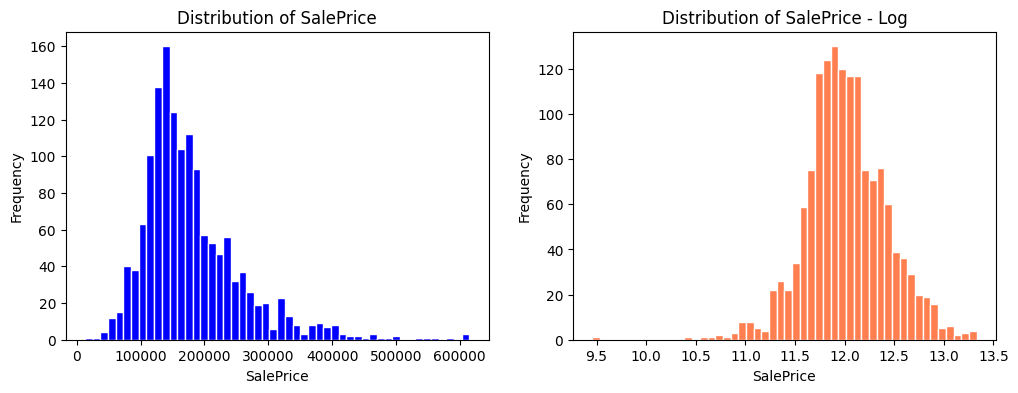

In [60]:
import numpy as np
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_train['SalePrice'], bins=50, color='blue', edgecolor='white')
axes[0].set_xlabel('SalePrice')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of SalePrice')

axes[1].hist(np.log1p(df_train['SalePrice']), bins=50, color='coral', edgecolor='white')
axes[1].set_xlabel('SalePrice')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of SalePrice - Log')

Text(0, 0.5, 'Missing Rate')

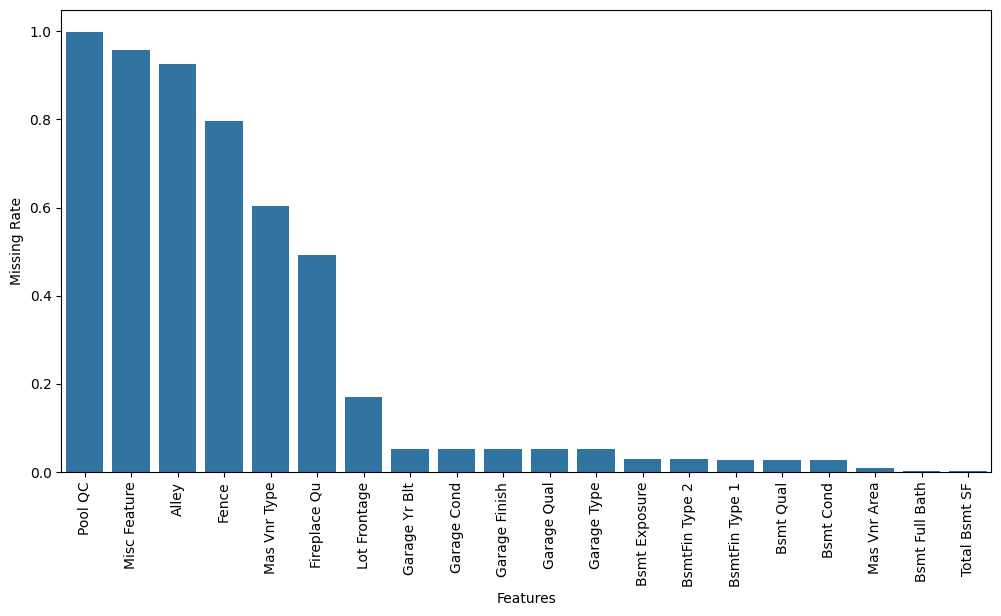

In [61]:
X_raw = df_train.drop('SalePrice', axis=1)
y = df_train['SalePrice']

missing_rate = X_raw.isnull().mean().sort_values(ascending=False)
missing_top = missing_rate[missing_rate > 0].head(20)

plt.figure(figsize=(12, 6))
sns.barplot(x=missing_top.index, y=missing_top.values)
plt.xticks(rotation=90)
plt.xlabel('Features')
plt.ylabel('Missing Rate')

In [62]:
drop_rate = 0.2
drop_cols = missing_rate[missing_rate > drop_rate].index.tolist()
print('Drop columns: ', drop_cols)

Drop columns:  ['Pool QC', 'Misc Feature', 'Alley', 'Fence', 'Mas Vnr Type', 'Fireplace Qu']


In [63]:
id_cols = [c for c in X_raw.columns if c.lower() in ['id', 'pid', 'order']]
remove_cols = id_cols + drop_cols

X = X_raw.drop(remove_cols, axis=1)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_val.shape, y_train.shape, y_val.shape)

(1168, 73) (292, 73) (1168,) (292,)


In [64]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

print('Số cột là số: ', len(num_cols))
print('Số cột là chuỗi: ', len(cat_cols))

Số cột là số:  36
Số cột là chuỗi:  37


In [65]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

X_train_num = num_imputer.fit_transform(X_train[num_cols])
X_train_cat = cat_imputer.fit_transform(X_train[cat_cols])

X_val_num = num_imputer.transform(X_val[num_cols])
X_val_cat = cat_imputer.transform(X_val[cat_cols])

print(np.isnan(X_train_num).sum())
print(np.isnan(X_val_num).sum())

0
0


In [66]:
ohe = OneHotEncoder(handle_unknown='ignore')
X_train_cat_enc = ohe.fit_transform(X_train_cat)
X_val_cat_enc = ohe.transform(X_val_cat)

print(X_train_cat_enc.shape)

(1168, 225)


In [67]:
ss = StandardScaler()
X_train_num_scaled = ss.fit_transform(X_train_num)
X_val_num_scaled = ss.transform(X_val_num)

print(X_train_num_scaled.shape)

(1168, 36)


In [68]:
print(X_train_num_scaled.shape, X_train_cat_enc.shape)
print(X_val_num_scaled.shape, X_val_cat_enc.shape)

(1168, 36) (1168, 225)
(292, 36) (292, 225)


In [69]:
X_train_final = np.hstack([X_train_num_scaled, X_train_cat_enc.toarray()])
X_val_final = np.hstack([X_val_num_scaled, X_val_cat_enc.toarray()])

print(X_train_final.shape)
n_features = X_train_final.shape[1]

print('Tổng features: ', n_features)

print(X_train_final.shape)
print(X_val_final.shape)

(1168, 261)
Tổng features:  261
(1168, 261)
(292, 261)


In [70]:
# Xây dựng mô hình dự báo chính xác giá nhà
model = Sequential(
    [
        Input(shape=(n_features,)),
        # Hidden layer 1
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        # Hidden layer 2
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        # Hidden layer 3
        Dense(64, activation='relu'),
        # Output
        Dense(1)
    ]
)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mse']
)

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 256)            │        67,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,825 (429.00 KB)

 Trainable params: 109,057 (426.00 KB)

 Non-trainable params: 768 (3.00 KB)

In [71]:
callback = [
    EarlyStopping(monitor='val_loss', patience=15, verbose=1, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, verbose=1, min_lr=1e-6)
]

history = model.fit(
    X_train_final, y_train,
    validation_data=(X_val_final, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callback,
    verbose=1
)

Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 37713518592.0000 - mse: 37713518592.0000 - val_loss: 41130881024.0000 - val_mse: 41130881024.0000 - learning_rate: 0.0010
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 37705871360.0000 - mse: 37705871360.0000 - val_loss: 41118638080.0000 - val_mse: 41118638080.0000 - learning_rate: 0.0010
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 37686759424.0000 - mse: 37686759424.0000 - val_loss: 41093574656.0000 - val_mse: 41093574656.0000 - learning_rate: 0.0010
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 37652688896.0000 - mse: 37652688896.0000 - val_loss: 41049604096.0000 - val_mse: 41049604096.0000 - learning_rate: 0.0010
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 37599268864.0000 - mse: 37599268864.0000 - val_loss: 40974622720.0000 - val_mse: 40974622720.0000 - learning_rate: 0.0010
Epoch 6/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 37522358272.0000 - mse: 3752235827

In [72]:
y_pred = model.predict(X_val_final).ravel()
rmse = np.sqrt(np.mean((y_pred - y_val)**2))
print('RMSE: ', rmse)

mae = np.mean(np.abs(y_pred - y_val))
print('MAE: ', mae)

r2 = r2_score(y_val, y_pred)
print('R2: ', r2)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
RMSE:  38351.63340083878
MAE:  25155.102614311323
R2:  0.8015154600143433


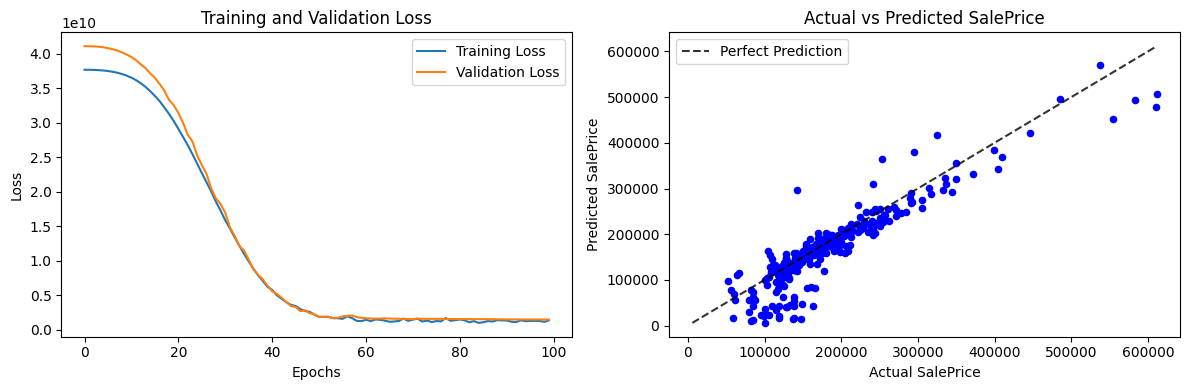

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()

axes[1].scatter(y_val, y_pred, color='blue', s=20)
lims = [min(y_val.min(), y_pred.min()), max(y_val.max(), y_pred.max())]
axes[1].plot(lims, lims, 'k--', alpha=0.8, label='Perfect Prediction')
axes[1].set_xlabel('Actual SalePrice')
axes[1].set_ylabel('Predicted SalePrice')
axes[1].set_title('Actual vs Predicted SalePrice')
axes[1].legend()

plt.tight_layout()
plt.show()

In [74]:
q1 = y_train.quantile(0.33)
q2 = y_train.quantile(0.66)

print(q1, q2)

139000.0 188110.0


In [75]:
def convert_class(price):
  return 0 if price < q1 else 1 if price < q2 else 2

y_train_class = y_train.map(convert_class).values
y_val_class = y_val.map(convert_class).values

In [76]:
from tensorflow.keras.regularizers import l2
n_classes = 3
model = Sequential(
    [
        Input(shape=(n_features,)),
        # Hidden layer 1
        Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(0.4),
        # Hidden layer 2
        Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(0.3),
        # Hidden layer 3
        Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(0.2),
        # Output
        Dense(n_classes, activation='softmax')
    ]
)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (None, 128)            │        33,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,867 (175.26 KB)

 Trainable params: 44,419 (173.51 KB)

 Non-trainable params: 448 (1.75 KB)

In [77]:
callback = [
    EarlyStopping(monitor='val_loss', patience=15, verbose=1, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1, min_lr=1e-6)
]

history = model.fit(
    X_train_final, y_train_class,
    validation_data=(X_val_final, y_val_class),
    epochs=100,
    batch_size=32,
    callbacks=callback,
    verbose=1
)

Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5308 - loss: 1.3635 - val_accuracy: 0.6541 - val_loss: 1.0552 - learning_rate: 0.0010
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6884 - loss: 0.9645 - val_accuracy: 0.7500 - val_loss: 0.8968 - learning_rate: 0.0010
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7680 - loss: 0.8266 - val_accuracy: 0.7705 - val_loss: 0.7978 - learning_rate: 0.0010
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7945 - loss: 0.7564 - val_accuracy: 0.7911 - val_loss: 0.7288 - learning_rate: 0.0010
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8014 - loss: 0.7414 - val_accuracy: 0.7877 - val_loss: 0.6920 - learning_rate: 0.0010
Epoch 6/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8134 - loss: 0.6798 - val_accuracy: 0.7911 - val_loss: 0.6973 - learning_rate: 0.0010
Epoch 7/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8399 - loss: 0.6594 - val_ac

In [78]:
y_pred = model.predict(X_val_final).argmax(axis=1)
acc = accuracy_score(y_val_class, y_pred)
print('Accuracy: ', acc)
f1 = f1_score(y_val_class, y_pred, average='weighted')
print('F1 Score: ', f1)
cm = confusion_matrix(y_val_class, y_pred)
print('Confusion Matrix: \n', cm)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Accuracy:  0.8321917808219178
F1 Score:  0.8310734018423832
Confusion Matrix: 
 [[76 13  0]
 [14 75 13]
 [ 0  9 92]]


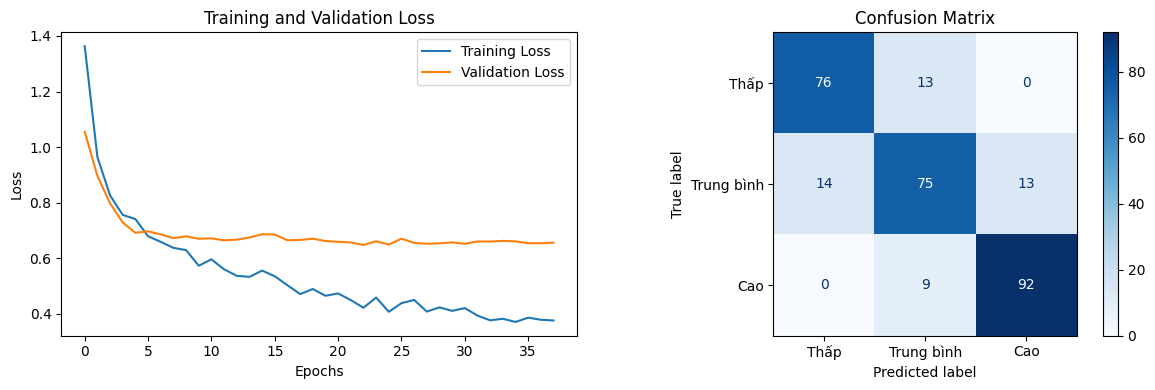

In [79]:
from sklearn.metrics import ConfusionMatrixDisplay
fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()

class_labels = ['Thấp', 'Trung bình', 'Cao']
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(ax=axes[1], cmap=plt.cm.Blues, values_format='d')
axes[1].set_title('Confusion Matrix')

plt.tight_layout()
plt.show()